<a href="https://colab.research.google.com/github/rayonli/ITA-Entregas/blob/Sprint-9/Sprint9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 9

##Nivell 1 - Visualització analítica guiada en Python

###Exercici 1: Preguntes analítiques directes (sense integracions complexes)
🌍 Context: Es treballa amb una sola taula a la vegada, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.
Aspectes a revisar i analitzar:

» Identificar quina informació és necessàriaQuin DataFrame és el més adequat per respondre la pregunta.
» Escollir correctament la taula (o taules) rellevant(s).
» Tipus de variables implicades.
» Elecció del tipus de gràfic.
Preguntes analítiques: (només utilitzant la taula de transaccions) :

👉 Per a cada pregunta:
Construeix una visualització senzilla en Python sense utilitzar IA.
Interpreta breument el resultat obtingut.
Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

####Pregunta 1: Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

Selecciona la columna temporal adequada.
Defineix el nivell
icona enllaç extern
temporal
d'anàlisi.
Compta el nombre de registres per període temporal.
Ordena els resultats cronològicament.
Visualitza l'evolució amb un gràfic de línies amb pandas.

   year  num_transactions
0  2015              9869
1  2016              9853
2  2017              9914
3  2018              9909
4  2019             10012
5  2020             10090
6  2021             10294
7  2022             10102
8  2023              9983
9  2024              9949


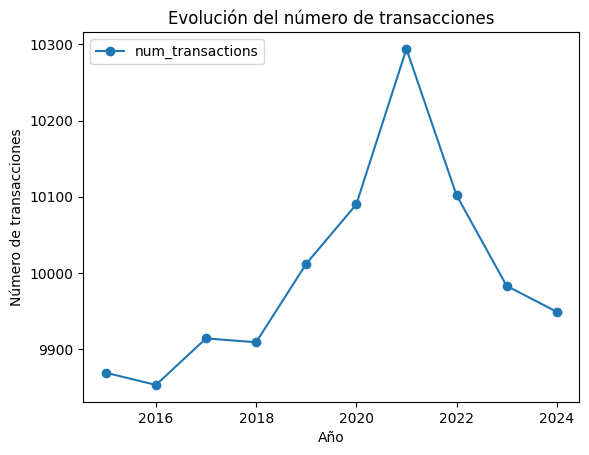

In [2]:
import pandas as pd

# Cargar el archivo CSV
transactions = pd.read_csv("tramnsactions.csv")

# Convertir timestamp a formato fecha/hora
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

# Crear una columna con el año
transactions["year"] = transactions["timestamp"].dt.year

# Agrupar las transacciones por año y contar registros
transactions_year = (
    transactions.groupby("year")
    .size()
    .reset_index(name="num_transactions")
    .sort_values("year")
)

# Mostrar los resultados
print(transactions_year)

# Crear el gráfico de líneas
transactions_year.plot(
    x="year",
    y="num_transactions",
    kind="line",
    title="Evolución del número de transacciones",
    xlabel="Año",
    ylabel="Número de transacciones",
    marker="o"
);

#####Razonamiento: Parto del DataFrame transactions y utilizo la columna timestamp porque contiene la información temporal de cada transacción. Extraigo el año de cada registro, agrupo las transacciones por año y cuento cuántos registros hay en cada grupo. Después ordeno los años cronológicamente y represento el resultado mediante un gráfico de líneas para visualizar la evolución temporal.


#####Interpretación: El número de transacciones se mantiene relativamente estable a lo largo del periodo analizado, en torno a 10.000 operaciones anuales. Se observa una ligera tendencia creciente desde 2016 hasta 2021, año en el que se alcanza el máximo con 10.294 transacciones. A partir de 2021 se produce un descenso progresivo hasta llegar a 9.950 transacciones en 2024. En conjunto, las variaciones son moderadas, por lo que no se observa un crecimiento estructural sostenido del volumen de transacciones.

#####Comparación con IA

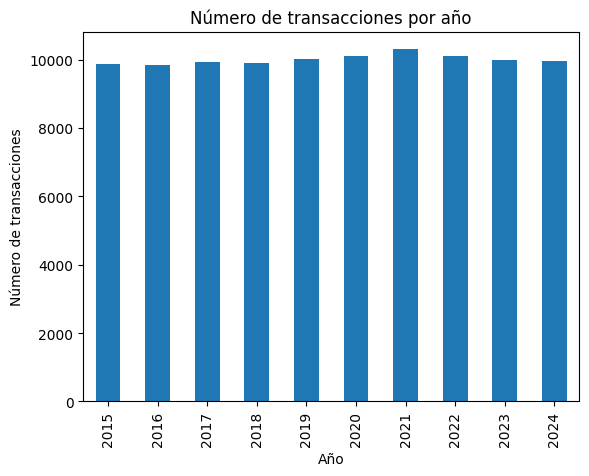

In [3]:
transactions_year.plot(
    x="year",
    y="num_transactions",
    kind="bar",
    title="Número de transacciones por año",
    xlabel="Año",
    ylabel="Número de transacciones",
    legend=False
);

#####Visualización alternativa propuesta por IA: Se propone un gráfico de barras para representar el número de transacciones de cada año. Esta visualización facilita la comparación directa entre los distintos años y permite identificar rápidamente qué periodos presentan un mayor o menor volumen. Considero que el gráfico de líneas es más adecuado para esta pregunta, ya que el objetivo principal es analizar la evolución del número de transacciones a lo largo del tiempo. El gráfico de líneas permite identificar de forma más clara la tendencia creciente hasta 2021 y el posterior descenso. El gráfico de barras sería una alternativa válida para comparar valores anuales, pero aporta menos información sobre la evolución temporal.

####Pregunta 2: Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.

Identifica la columna que representa el usuari.
Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
Ordena els usuaris de major a menor volum de facturació.
Selecciona els N usuaris principals (per exemple, els 15 primers).
Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

     user_id  total_amount
288      289      47332.90
317      318      47133.55
454      455      40803.86
416      417      37393.91
184      185      34576.49
284      285      33383.56
453      454      29528.42
348      349      27835.38
192      193      27462.59
316      317      22484.76
387      388      21313.31
442      443      20605.24
318      319      20455.52
392      393      19632.36
436      437      18518.81


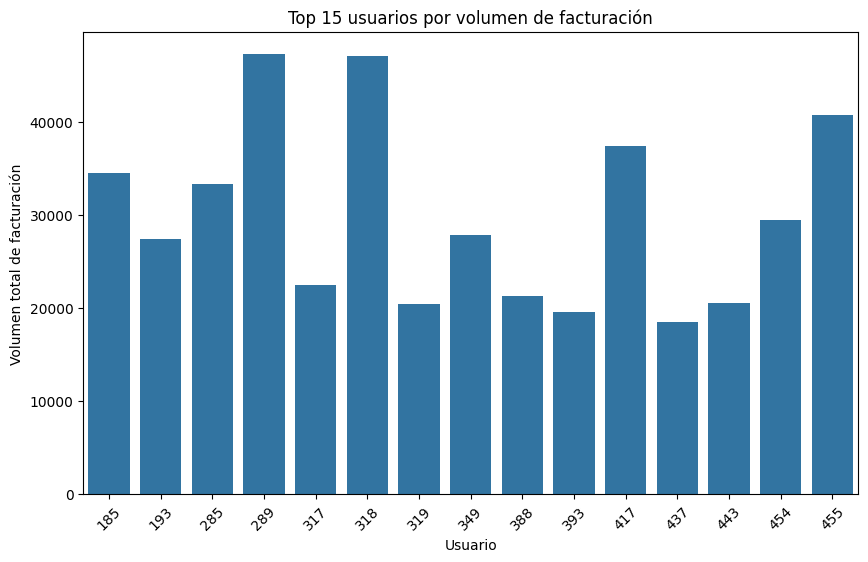

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Agrupar las transacciones por usuario y sumar el importe
user_amount = (
    transactions.groupby("user_id")["amount"]
    .sum()
    .reset_index(name="total_amount")
)

# Ordenar de mayor a menor facturación
user_amount = user_amount.sort_values(
    by="total_amount",
    ascending=False
)

# Seleccionar los 15 usuarios con mayor facturación
top_15_users = user_amount.head(15)

# Mostrar los resultados
print(top_15_users)

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_15_users,
    x="user_id",
    y="total_amount"
)

plt.title("Top 15 usuarios por volumen de facturación")
plt.xlabel("Usuario")
plt.ylabel("Volumen total de facturación")

plt.xticks(rotation=45)

plt.show()

#####Razonamiento :Parto del DataFrame transactions. Identifico user_id como la variable que identifica al usuario y amount como el importe de cada transacción. Agrupo las transacciones por user_id y sumo los importes de cada grupo para obtener el volumen total de facturación generado por cada usuario. Ordeno los usuarios de mayor a menor facturación y selecciono los 15 primeros. Finalmente, represento estos usuarios mediante un gráfico de barras utilizando Seaborn.

#####Interpretación: El usuario 289 presenta el mayor volumen de facturación, con 47.332,90, seguido muy de cerca por el usuario 318, con 47.133,55. A partir de estos dos usuarios se observa un descenso progresivo del volumen de facturación. El usuario situado en la posición 15 genera 18.518,81, aproximadamente 2,5 veces menos que el primero. Por tanto, dentro de los 15 usuarios con mayor facturación existe una concentración significativa del volumen en los primeros puestos.

#####Comparación con IA

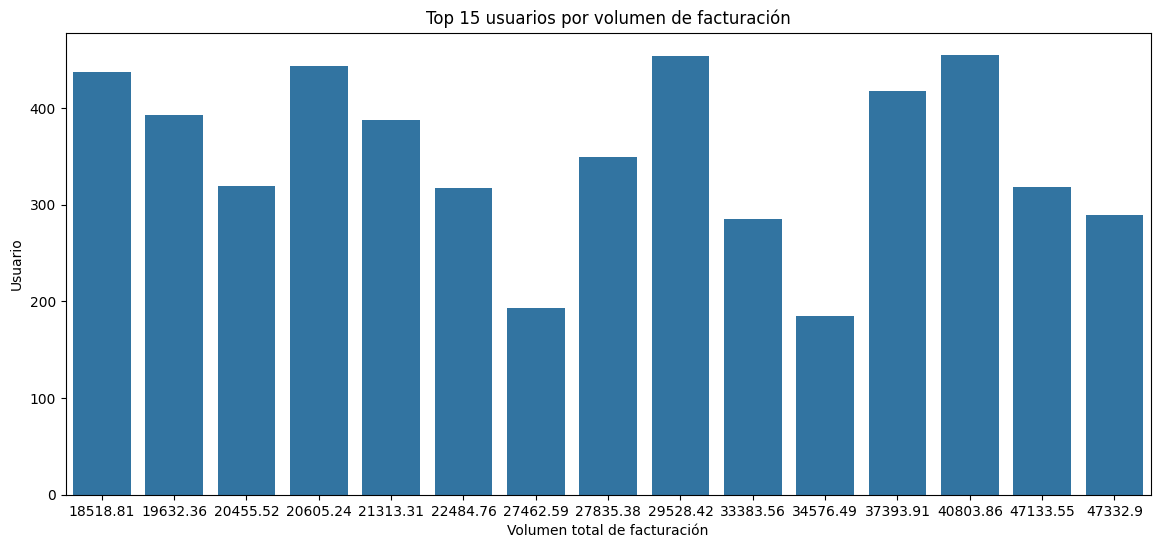

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

top_15_horizontal = top_15_users.sort_values(
    by="total_amount",
    ascending=True
).round(2)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=top_15_horizontal,
    x="total_amount",
    y="user_id"
)

plt.title("Top 15 usuarios por volumen de facturación")
plt.xlabel("Volumen total de facturación")
plt.ylabel("Usuario")

plt.show()

#####Visualización alternativa propuesta por IA: La propuesta alternativa mediante un gráfico de barras horizontales mejora la visualización inicial, ya que facilita la lectura de los identificadores de los usuarios y permite interpretar el ranking de forma más directa. El gráfico vertical también es válido, pero las etiquetas aparecen inclinadas y dificultan ligeramente la lectura cuando se representan 15 usuarios. Por este motivo, considero que la alternativa horizontal es más adecuada para comunicar este resultado.

####Pregunta 3: Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

Crea una nova columna amb l'hora del dia a partir del timestamp.
Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

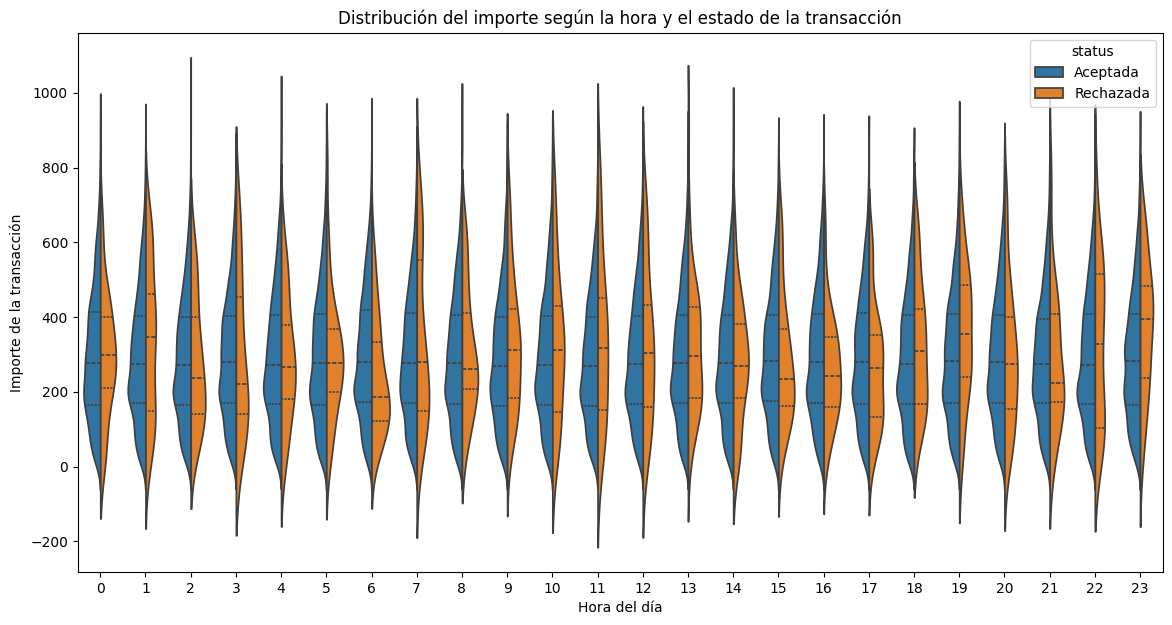

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Aseguramos que timestamp tenga formato de fecha/hora
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

# Crear una columna con la hora del día
transactions["hour"] = transactions["timestamp"].dt.hour

# Crear una columna con el estado de la transacción
transactions["status"] = transactions["declined"].map({
    0: "Aceptada",
    1: "Rechazada"
})

# Crear el violinplot
plt.figure(figsize=(14, 7))

sns.violinplot(
    data=transactions,
    x="hour",
    y="amount",
    hue="status",
    split=True,
    inner="quartile"
)

plt.title("Distribución del importe según la hora y el estado de la transacción")
plt.xlabel("Hora del día")
plt.ylabel("Importe de la transacción")

plt.show()

In [7]:
#Contar aceptadas vs rechazadas

transactions["status"].value_counts()

,count
status,
Aceptada,99087
Rechazada,888


#####Razonamiento: Parto del DataFrame transactions. Utilizo timestamp para obtener la hora del día de cada transacción y creo una nueva columna con esa información. Después utilizo amount como variable numérica para analizar la distribución de los importes y declined para distinguir entre transacciones aceptadas y rechazadas. Finalmente, represento la distribución del importe para cada hora mediante un violinplot de Seaborn, separando visualmente los dos estados para poder compararlos.

#####Interpretación: El importe de las transacciones presenta una distribución relativamente similar a lo largo de las diferentes horas del día, aunque existen pequeñas variaciones en las medianas y en la dispersión. Las distribuciones de las operaciones aceptadas y rechazadas presentan bastante solapamiento, por lo que no se identifica un patrón horario claramente diferenciado entre ambos estados. No obstante, la comparación debe interpretarse con precaución, ya que la muestra está muy desequilibrada: 99.087 transacciones son aceptadas y únicamente 888 son rechazadas, lo que representa aproximadamente un 0,89 % del total.

#####Comparación con la IA

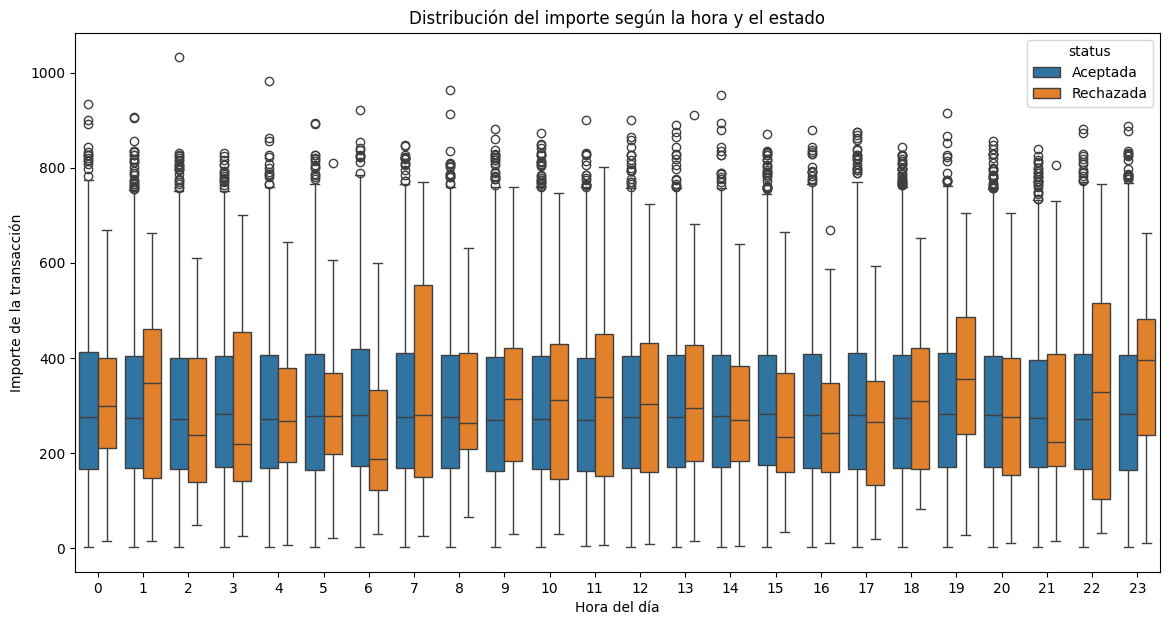

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=transactions,
    x="hour",
    y="amount",
    hue="status"
)

plt.title("Distribución del importe según la hora y el estado")
plt.xlabel("Hora del día")
plt.ylabel("Importe de la transacción")

plt.show()

#####Visualización alternativa propuesta por la IA: La visualización alternativa mediante un boxplot facilita la comparación de las medianas, los cuartiles y la dispersión de los importes entre las diferentes horas y estados. Sin embargo, considero que el violinplot es más adecuado para esta pregunta porque permite observar con mayor detalle la forma de las distribuciones. Por ello, considero que la alternativa propuesta por IA es válida, pero no supone una mejora clara respecto a la visualización original.

####Pregunta 4: Quins dies de la setmana es concentra més activitat de venda?

  day_of_week  num_transactions
0       Lunes             14122
1      Martes             14176
2   Miércoles             14271
3      Jueves             14516
4     Viernes             14272
5      Sábado             14353
6     Domingo             14265


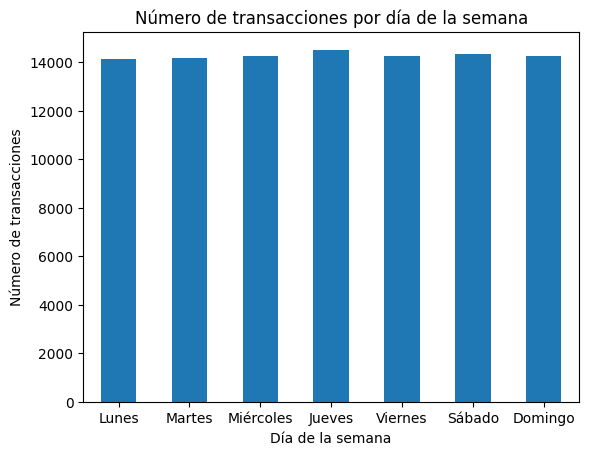

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Aseguramos que timestamp tenga formato fecha/hora
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

# Crear una columna con el día de la semana
transactions["day_of_week"] = transactions["timestamp"].dt.day_name()

# Definir el orden correcto de los días
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Contar las transacciones de cada día
transactions_day = (
    transactions.groupby("day_of_week")
    .size()
    .reindex(days_order)
    .reset_index(name="num_transactions")
)

# Traducir los días al español
transactions_day["day_of_week"] = transactions_day["day_of_week"].map({
    "Monday": "Lunes",
    "Tuesday": "Martes",
    "Wednesday": "Miércoles",
    "Thursday": "Jueves",
    "Friday": "Viernes",
    "Saturday": "Sábado",
    "Sunday": "Domingo"
})

# Mostrar los resultados
print(transactions_day)

# Crear el gráfico de barras
transactions_day.plot(
    x="day_of_week",
    y="num_transactions",
    kind="bar",
    title="Número de transacciones por día de la semana",
    xlabel="Día de la semana",
    ylabel="Número de transacciones",
    legend=False
)

plt.xticks(rotation=0)
plt.show()

#####Razonamiento: Parto del DataFrame transactions y utilizo la columna timestamp, ya que contiene la fecha de cada transacción. A partir de ella extraigo el día de la semana. Después agrupo las transacciones según ese día y cuento cuántas operaciones se realizan en cada uno. Finalmente, ordeno los días de lunes a domingo y represento los resultados mediante un gráfico de barras para comparar el nivel de actividad de cada día.

#####Interpretación: La actividad de venta se encuentra bastante equilibrada entre los siete días de la semana. El jueves concentra el mayor número de transacciones, con 14.516 operaciones, mientras que el lunes presenta el menor volumen, con 14.122. La diferencia entre ambos días es de solo 394 transacciones, aproximadamente un 2,8 %, por lo que no se observa una concentración muy marcada de la actividad en un día concreto. Además, la actividad durante el fin de semana se mantiene en niveles similares a los días laborables.

#####Comparación con IA

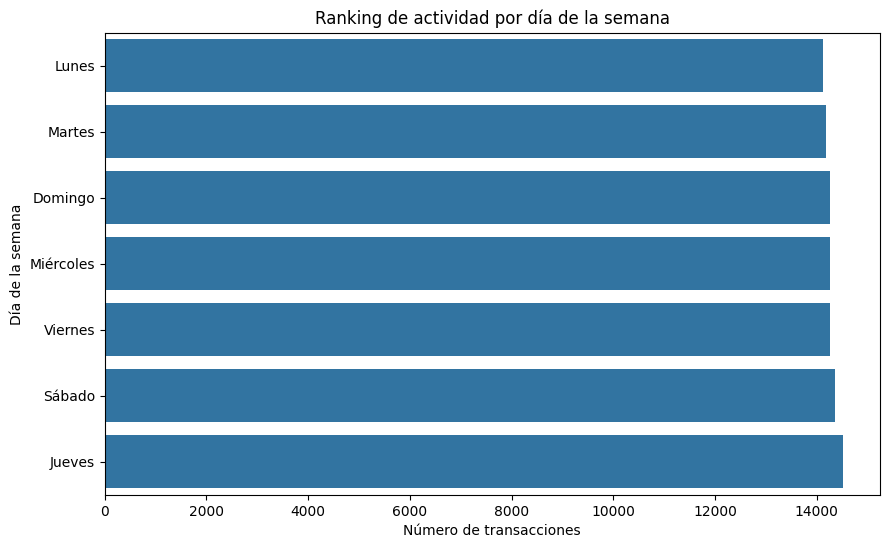

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

transactions_day_sorted = transactions_day.sort_values(
    by="num_transactions",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=transactions_day_sorted,
    x="num_transactions",
    y="day_of_week"
)

plt.title("Ranking de actividad por día de la semana")
plt.xlabel("Número de transacciones")
plt.ylabel("Día de la semana")

plt.show()

#####Visualización alternativa propuesta por la IA: La alternativa mediante un gráfico de barras horizontal ordenado facilita la identificación del ranking de actividad y permite detectar rápidamente qué días presentan un mayor volumen de transacciones. Sin embargo, considero que la visualización original es más adecuada para este análisis porque mantiene el orden natural de los días de la semana y permite observar mejor la distribución de la actividad a lo largo de toda la semana. Por tanto, la alternativa es útil para mostrar un ranking, pero no supone una mejora clara para esta pregunta concreta.

###Exercici 2: Preguntes analítiques complexes (amb guia)
🌍 Context: Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

» Fer merge entre taules.
» Utilitzar groupby, pivot_table, crosstab...
» Aplicar agregacions, transformacions intermèdies i funcions.
Preguntes analítiques (amb guia general)

» Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.
2. Agrupar la facturació per país.
3. Calcular la facturació total generada per cada país.
4. Ordenar els països de major a menor facturació.
5. Calcular el percentatge acumulat sobre el total.
6. Visualitzar.
» Existeix estacionalitat en les vendes?

Passos orientatius:

1. Treballar amb dates de transacció.
2. Extreure la informació temporal rellevant (any i mes).
3. Calcular el volum total de vendes (suma de amount) per any i mes.
4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.
5. Visualitzar l'evolució.
» Anàlisi de concentració i variabilitat (tria UNA opció)

Opció A – Producte (Només si disposes de la taula de productes)

Quins productes generen més ingressos i amb quina variabilitat?

Passos orientatius:

1. Combinar transaccions, la taula pont i productes.
2. Calcular ingressos per producte amb un groupby, sum y sort.
3. Selecciona els top N productes: 15 per exemple.
4. Escollir una visualització adequada per analitzar dispersió.
Opció B – Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

Hi ha usuaris que han deixat de comprar recentment?

Passos orientatius:

1. Identificar l'última compra per usuari.
2. Calcular el temps des de l'última compra.
3. Visualitzar la distribució del temps des de l'última compra.
» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.
2. Construir una taula agregada utilitzant crosstab.
3. Visualitzar amb un heatmap.
👉 Per a cada pregunta:

» Descriu breument els passos seguits.
» Mostra la visualització final.
» Interpreta què implica per al negoci.

FACTURACIÓN POR PAÍS DE COMPAÑÍA


,country,total_revenue,revenue_percentage,cumulative_percentage
12,Sweden,4926959.37,16.82,16.82
8,Netherlands,4503620.17,15.38,32.20
13,United Kingdom,4098515.59,13.99,46.19
7,Italy,4087349.10,13.96,60.15
5,Germany,4019067.95,13.72,73.87
4,France,1416084.26,4.83,78.71
14,United States,1101657.86,3.76,82.47
1,Belgium,951669.99,3.25,85.72
10,Norway,809288.82,2.76,88.48
6,Ireland,714959.02,2.44,90.92



Número de países: 15

Facturación acumulada Top 3: 46.19 %

Facturación acumulada Top 5: 73.87 %



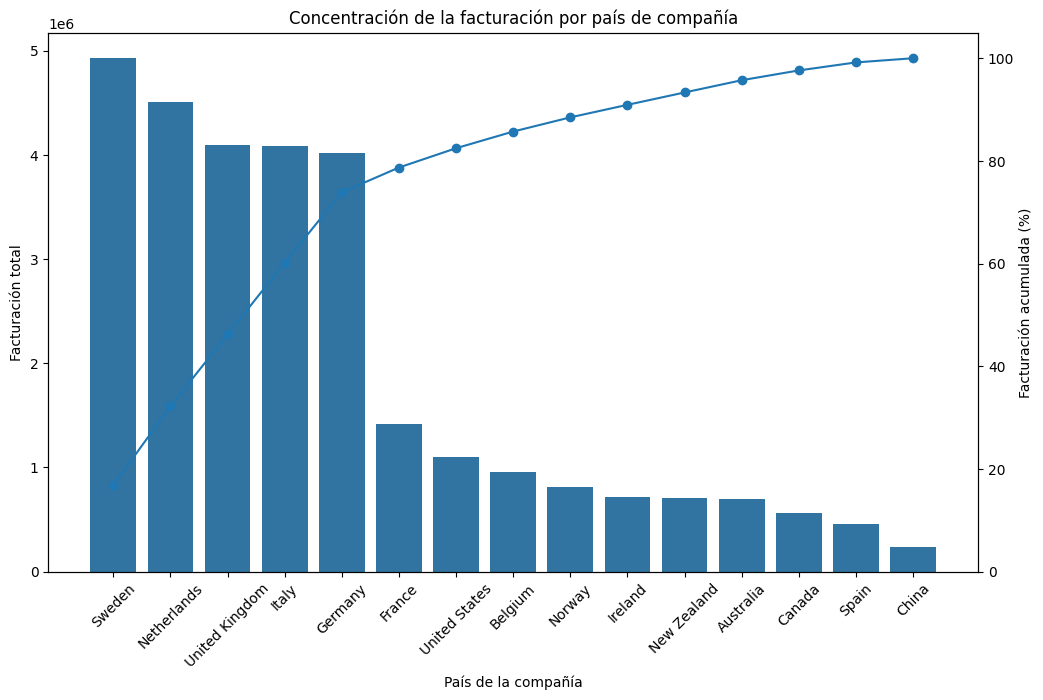


FACTURACIÓN MENSUAL POR AÑO


,Ene,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep,Oct,Nov,Dic
year,,,,,,,,,,,,
2015,224946.23,248775.83,254623.57,247957.49,252596.43,233084.63,243774.43,238550.36,227985.24,244420.98,228805.24,237169.43
2016,227231.14,251111.47,248207.57,242394.40,243533.92,233245.79,238618.15,238392.03,242774.67,251681.54,235185.22,237315.90
2017,224391.23,253354.90,239745.23,253125.97,240919.28,241065.64,244380.32,233894.55,235830.55,244385.66,243671.03,252058.49
2018,229524.09,246504.98,238509.59,237432.05,246838.08,243421.44,233449.29,231129.56,238772.22,257709.49,242636.18,234974.71
2019,224592.71,262006.66,279660.93,244347.66,244739.50,245470.13,233962.91,240040.21,235021.45,253133.66,233477.03,255307.10
2020,234191.13,249356.44,260038.46,246533.40,254171.48,238902.90,242644.23,234433.92,258779.26,260928.72,224595.34,246449.95
2021,246993.53,258837.10,251612.31,261597.02,243414.73,236504.81,253553.62,239433.71,247648.05,268417.75,242538.98,243737.57
2022,226680.93,237503.38,273194.34,241191.04,279590.23,261954.89,235935.19,246434.63,255496.48,258033.06,233416.07,239045.01
2023,231075.91,252680.15,243332.35,245386.83,264790.26,234527.22,240041.34,239288.98,237105.34,251431.72,235827.93,236690.04



PROMEDIO DE FACTURACIÓN POR MES


,0
Oct,254586.27
Mar,253668.63
May,252847.14
Feb,251387.06
Abr,246570.01
Dic,243443.71
Sep,241600.58
Jun,241520.70
Jul,239762.37
Ago,238080.86


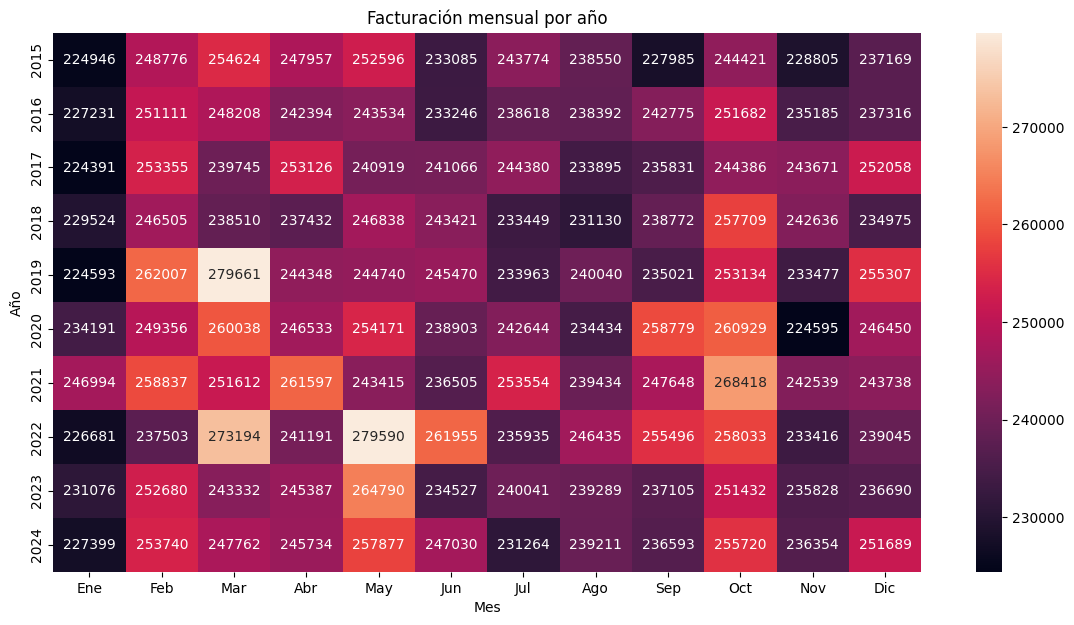

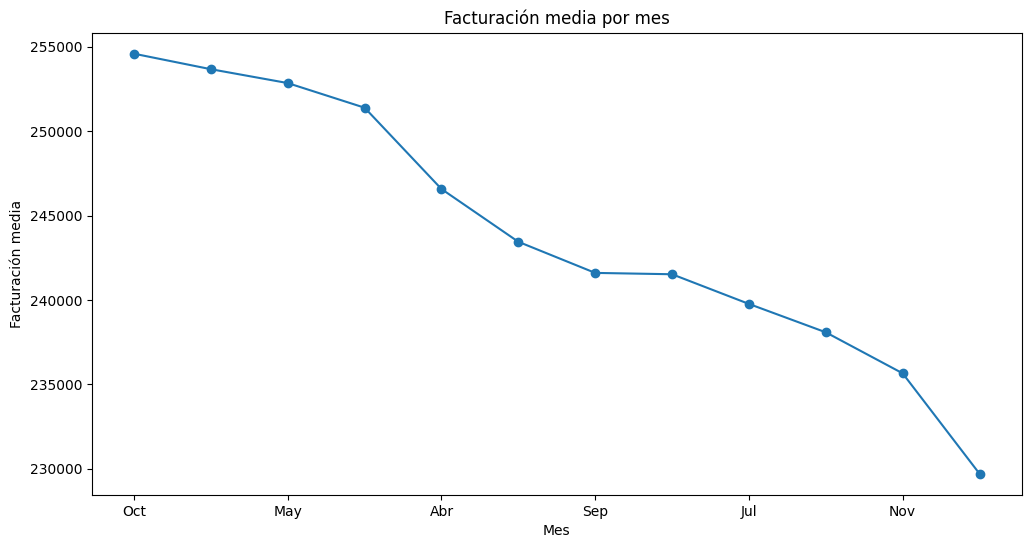


TOP 15 PRODUCTOS POR INGRESOS


,product_id,product_name,total_revenue,revenue_variability
38,39,warden,568721.79,16.39
63,64,Direwolf,566093.17,16.63
66,67,Winterfell,562243.64,16.65
14,15,Stannis warden,553687.72,16.44
92,93,Littlefinger Tarly Stark,549400.85,15.91
61,62,the duel,541794.07,16.27
85,86,Stark kingsblood,538536.06,16.07
62,63,Jade tatooine dooku,535859.30,15.61
15,16,the duel warden,531671.36,14.80
11,12,duel Direwolf,523078.64,15.45


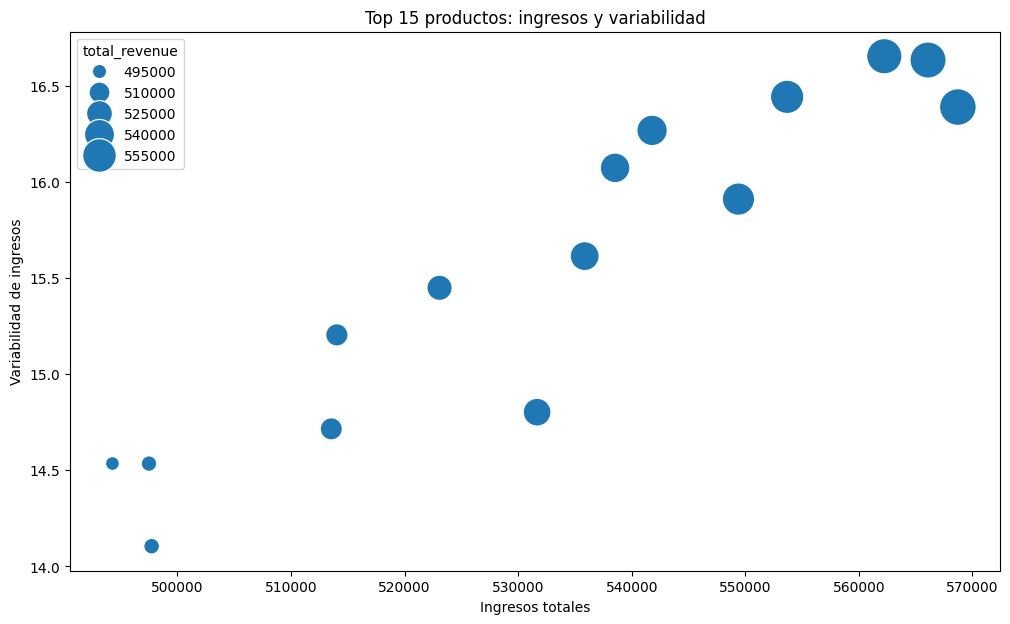


ACTIVIDAD DE VENTA POR FRANJA HORARIA Y AÑO


time_period,Madrugada,Mañana,Tarde,Noche
year,,,,
2015,2451,2461,2457,2500
2016,2473,2481,2510,2389
2017,2443,2476,2554,2441
2018,2520,2425,2508,2456
2019,2464,2554,2544,2450
2020,2612,2471,2472,2535
2021,2585,2584,2593,2532
2022,2565,2457,2520,2560
2023,2514,2551,2464,2454



PORCENTAJE DE ACTIVIDAD POR FRANJA Y AÑO


time_period,Madrugada,Mañana,Tarde,Noche
year,,,,
2015,24.84,24.94,24.90,25.33
2016,25.10,25.18,25.47,24.25
2017,24.64,24.97,25.76,24.62
2018,25.43,24.47,25.31,24.79
2019,24.61,25.51,25.41,24.47
2020,25.89,24.49,24.50,25.12
2021,25.11,25.10,25.19,24.60
2022,25.39,24.32,24.95,25.34
2023,25.18,25.55,24.68,24.58


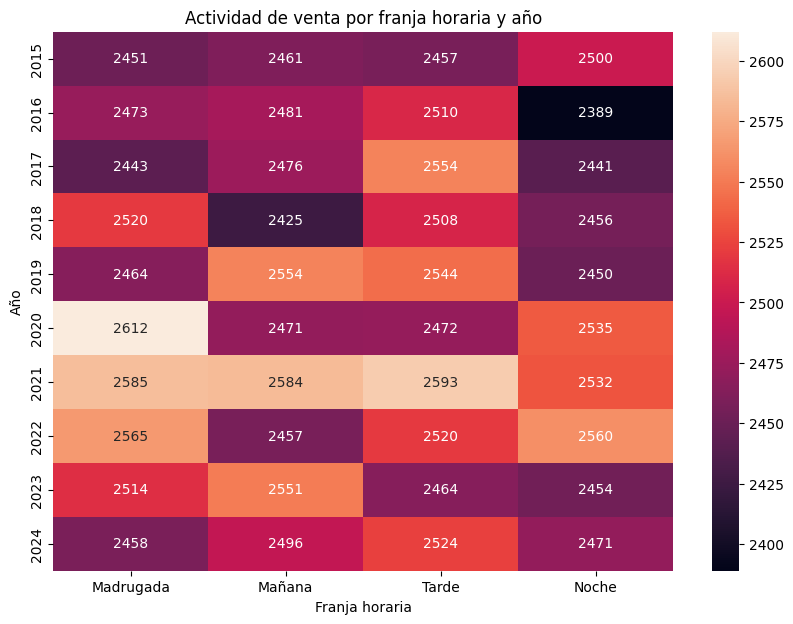

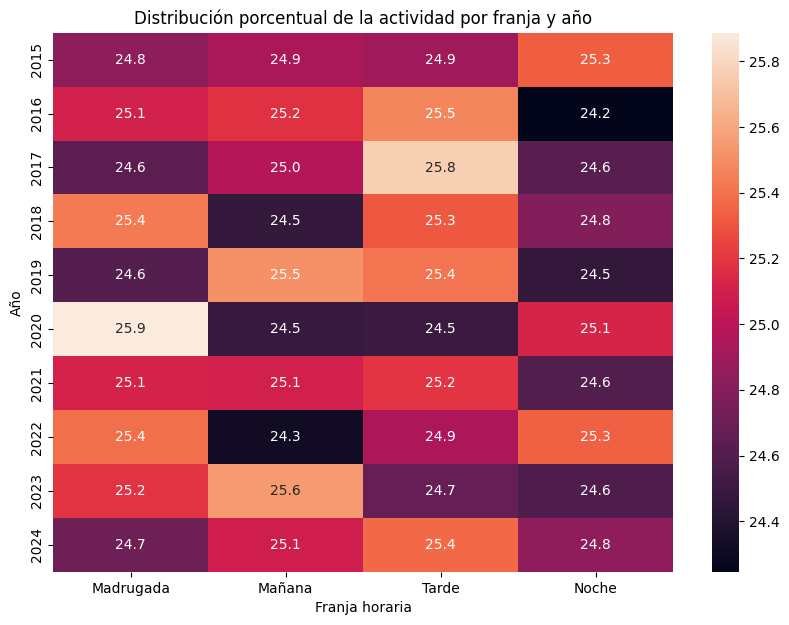

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos

transactions = pd.read_csv("tramnsactions.csv")
companies = pd.read_csv("companies.csv")
products = pd.read_csv("products.csv")

# Convertir timestamp a fecha/hora

transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"]
)

# Convertir amount a numérico

transactions["amount"] = pd.to_numeric(
    transactions["amount"],
    errors="coerce"
)

# Convertir price a numérico

products["price"] = (
    products["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .astype(float)
)

# PREGUNTA 1: ¿Dependemos excesivamente de un número reducido de países
# de compañías vendedoras?

# 1. Combinar transactions con companies

country_analysis = transactions.merge(
    companies[["company_id", "country"]],
    left_on="business_id",
    right_on="company_id",
    how="left"
)

# 2. Agrupar la facturación por país

country_revenue = (
    country_analysis
    .groupby("country")["amount"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

# 3. Porcentaje de facturación

country_revenue["revenue_percentage"] = (
    country_revenue["total_revenue"]
    / country_revenue["total_revenue"].sum()
    * 100
)

# 4. Porcentaje acumulado

country_revenue["cumulative_percentage"] = (
    country_revenue["revenue_percentage"].cumsum()
)

# Mostrar tabla
print("FACTURACIÓN POR PAÍS DE COMPAÑÍA")
display(
    country_revenue.round(2)
)

# 5. Indicadores de concentración

top_3 = (
    country_revenue["revenue_percentage"]
    .head(3)
    .sum()
)

top_5 = (
    country_revenue["revenue_percentage"]
    .head(5)
    .sum()
)

print("")
print(
    "Número de países:",
    country_revenue.shape[0]
)

print("")
print(
    "Facturación acumulada Top 3:",
    round(top_3, 2),
    "%"
)

print("")
print(
    "Facturación acumulada Top 5:",
    round(top_5, 2),
    "%"
)

# 6. Visualización

fig, ax1 = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=country_revenue,
    x="country",
    y="total_revenue",
    ax=ax1
)

ax1.set_title(
    "Concentración de la facturación por país de compañía"
)

ax1.set_xlabel(
    "País de la compañía"
)

ax1.set_ylabel(
    "Facturación total"
)

ax1.tick_params(
    axis="x",
    rotation=45
)


ax2 = ax1.twinx()

ax2.plot(
    range(len(country_revenue)),
    country_revenue["cumulative_percentage"],
    marker="o"
)

ax2.set_ylabel(
    "Facturación acumulada (%)"
)

ax2.set_ylim(0, 105)

print("")
plt.show()

# PREGUNTA 2
# ¿Existe estacionalidad en las ventas?

# 1. Extraer año y mes

transactions["year"] = (
    transactions["timestamp"].dt.year
)

transactions["month"] = (
    transactions["timestamp"].dt.month
)

# 2. Facturación por año y mes

sales_by_year_month = pd.pivot_table(
    transactions,
    values="amount",
    index="year",
    columns="month",
    aggfunc="sum",
    fill_value=0
)

# 3. Ordenar los meses

months_order = [
    1, 2, 3, 4, 5, 6,
    7, 8, 9, 10, 11, 12
]

sales_by_year_month = (
    sales_by_year_month
    .reindex(columns=months_order)
)


# Cambiar nombres de columnas
sales_by_year_month.columns = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

# Mostrar tabla

print("")
print("FACTURACIÓN MENSUAL POR AÑO")
display(
    sales_by_year_month.round(2)
)

# 4. Promedio de facturación por mes

monthly_average = (
    sales_by_year_month
    .mean(axis=0)
    .sort_values(ascending=False)
)

print("")
print("PROMEDIO DE FACTURACIÓN POR MES")
display(
    monthly_average.round(2)
)

# 5. Visualización

plt.figure(figsize=(14, 7))

sns.heatmap(
    sales_by_year_month,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Facturación mensual por año"
)

plt.xlabel("Mes")
plt.ylabel("Año")

print("")
plt.show()

# 6. Evolución mensual agregada

plt.figure(figsize=(12, 6))

monthly_average.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Facturación media por mes"
)

plt.xlabel("Mes")
plt.ylabel("Facturación media")

plt.xticks(rotation=0)

print("")
plt.show()

# PREGUNTA 3
# OPCIÓN A - PRODUCTOS
# ¿Qué productos generan más ingresos y con qué variabilidad?

# 1. Copia de transactions

tx_products = transactions.copy()

# 2. Separar product_ids

tx_products["product_ids"] = (
    tx_products["product_ids"]
    .fillna("")
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.split(",")
)

# 3. Una fila por producto

product_transactions = (
    tx_products
    .explode("product_ids")
    .copy()
)

# Eliminar valores vacíos
product_transactions = (
    product_transactions[
        product_transactions["product_ids"] != ""
    ]
)

# Convertir ID de producto a entero
product_transactions["product_id"] = (
    product_transactions["product_ids"]
    .astype(int)
)

# 4. Combinar con products

products_aux = (
    products[
        ["id", "product_name", "price"]
    ]
    .rename(
        columns={"id": "product_id"}
    )
)

product_transactions = (
    product_transactions
    .merge(
        products_aux,
        on="product_id",
        how="left"
    )
)

# 5. Repartir amount proporcionalmente al precio

product_transactions["transaction_product_total"] = (
    product_transactions
    .groupby("id")["price"]
    .transform("sum")
)

product_transactions["product_revenue"] = (
    product_transactions["amount"]
    * product_transactions["price"]
    / product_transactions["transaction_product_total"]
)

# Limitación metodológica

# transactions no proporciona el importe individual de cada producto cuando una
# transacción contiene varios productos. Por ello, distribuimos el amount total
# proporcionalmente según el precio de catálogo de cada producto.
# Esta aproximación evita duplicar los ingresos, pero no permite conocer el
# importe real pagado por cada producto.



# 6. Ingresos y variabilidad por producto

product_revenue = (
    product_transactions
    .groupby(
        ["product_id", "product_name"]
    )
    .agg(
        total_revenue=(
            "product_revenue",
            "sum"
        ),

        revenue_variability=(
            "product_revenue",
            lambda x: x.std(ddof=0)
        )
    )
    .reset_index()
)

# 7. Seleccionar Top 15

top_15_products = (
    product_revenue
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .head(15)
)

print("")
print("TOP 15 PRODUCTOS POR INGRESOS")
display(
    top_15_products.round(2)
)

# 8. Visualización

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=top_15_products,
    x="total_revenue",
    y="revenue_variability",
    size="total_revenue",
    sizes=(100, 700)
)

plt.title(
    "Top 15 productos: ingresos y variabilidad"
)

plt.xlabel(
    "Ingresos totales"
)

plt.ylabel(
    "Variabilidad de ingresos"
)

print("")
plt.show()

# PREGUNTA 4
# ¿Cómo varía la actividad de venta por franjas horarias
# a lo largo de los años?

# 1. Extraer la hora

transactions["hour"] = (
    transactions["timestamp"].dt.hour
)

# 2. Función para crear las franjas horarias

def get_time_period(hour):

    if 0 <= hour <= 5:
        return "Madrugada"

    elif 6 <= hour <= 11:
        return "Mañana"

    elif 12 <= hour <= 17:
        return "Tarde"

    else:
        return "Noche"

# 3. Aplicar la función

transactions["time_period"] = (
    transactions["hour"]
    .apply(get_time_period)
)

# 4. Crosstab

time_activity = pd.crosstab(
    transactions["year"],
    transactions["time_period"]
)

# 5. Ordenar las franjas

time_order = [
    "Madrugada",
    "Mañana",
    "Tarde",
    "Noche"
]

time_activity = (
    time_activity
    .reindex(
        columns=time_order,
        fill_value=0
    )
)

print("")
print("ACTIVIDAD DE VENTA POR FRANJA HORARIA Y AÑO")
display(time_activity)

# 6. Porcentaje de cada franja dentro de cada año

time_activity_percentage = (
    time_activity
    .div(
        time_activity.sum(axis=1),
        axis=0
    )
    * 100
)

print("")
print("PORCENTAJE DE ACTIVIDAD POR FRANJA Y AÑO")
display(
    time_activity_percentage.round(2)
)

# 7. Visualización: número de transacciones

plt.figure(figsize=(10, 7))

sns.heatmap(
    time_activity,
    annot=True,
    fmt=".0f"
)

plt.title(
    "Actividad de venta por franja horaria y año"
)

plt.xlabel(
    "Franja horaria"
)

plt.ylabel(
    "Año"
)

print("")
plt.show()

# 8. Visualización adicional: porcentajes

plt.figure(figsize=(10, 7))

sns.heatmap(
    time_activity_percentage,
    annot=True,
    fmt=".1f"
)

plt.title(
    "Distribución porcentual de la actividad por franja y año"
)

plt.xlabel(
    "Franja horaria"
)

plt.ylabel(
    "Año"
)

print("")
plt.show()

####Interpretación:
-Pregunta 1: La facturación está distribuida entre 15 países, pero existe una concentración relevante en los principales mercados. Los tres primeros países concentran el 46,19 % de la facturación y los cinco primeros alcanzan el 73,87 %.

Por tanto, el negocio no depende de un único país, pero sí presenta una dependencia significativa de un grupo reducido de mercados. Esta concentración supone un riesgo, ya que una caída de la actividad en alguno de los principales países podría afectar de forma importante a los ingresos. La diversificación geográfica podría reducir este riesgo.

-Pregunta 2: El análisis mensual muestra diferencias entre los niveles de facturación, aunque no se observa una estacionalidad especialmente fuerte. Octubre presenta la mayor facturación media mensual, con aproximadamente 254.586 €, mientras que enero registra la menor, con unos 229.703 €.

El heatmap muestra que algunos meses tienden a presentar valores relativamente altos o bajos en varios años, pero el patrón no es completamente constante. Por ello, podemos hablar de una cierta estacionalidad moderada, pero no de un patrón estacional fuerte y estable.

Desde el punto de vista de negocio, estas diferencias pueden ser útiles para ajustar campañas y planificación de recursos, aunque no justifican por sí solas una estrategia basada exclusivamente en la estacionalidad.

-Pregunta 3: Los 15 productos con mayores ingresos presentan un comportamiento relativamente homogéneo, con una facturación situada aproximadamente entre 494.000 € y 569.000 €. El producto con mayor facturación es "warden", con 568.722 €, seguido de "Direwolf" y "Winterfell".

La variabilidad de los ingresos también es bastante similar entre los productos analizados, situándose aproximadamente entre 14,1 y 16,8. Esto indica que los productos líderes presentan un comportamiento relativamente estable y que no existe una diferencia extrema en su variabilidad.

Desde el punto de vista del negocio, la facturación de los productos principales está relativamente repartida entre varios productos, lo que reduce el riesgo de depender exclusivamente de un único producto. No obstante, estos productos concentran una parte importante de los ingresos y deberían mantenerse bajo seguimiento.

-Pregunta 4: La actividad de venta está muy equilibrada entre las cuatro franjas horarias analizadas. En todos los años, cada franja concentra aproximadamente una cuarta parte de las transacciones, con valores que se sitúan generalmente entre el 24 % y el 26 %.

No se observa una franja horaria que domine de forma consistente ni cambios relevantes en este patrón a lo largo de los años. Por tanto, no existe un patrón horario fuerte de concentración de las ventas.

Desde el punto de vista del negocio, esto sugiere que la actividad está distribuida de manera bastante uniforme durante el día y que no sería necesario concentrar recursos exclusivamente en una determinada franja horaria.

##Nivell 2 – Anàlisi relacional i patrons avançats

###Exercici 1: Anàlisi de productes i captació d'usuaris
🎯 Objectiu: Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.
Els productes que generen més ingressos també impulsen el creixement del negoci mitjançant la captació de nous usuaris, o bé el negoci depèn principalment d'usuaris recurrents comprant els mateixos productes?

Passos orientatius:

1. Combina les taules necessàries.
2. Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.
3. Agrega la informació per producte i calcula les mètriques següents:

Ingressos totals.
Variabilitat dels ingressos.
Nombre de nous usuaris.
Percentatge de nous usuaris sobre el total de compradors del producte.
4. Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:

Captador: alta captació de nous usuaris.
Recurrent: ingressos elevats però baixa captació.
Emergent: baixa facturació però bona captació.
Estancat: baixos ingressos i baixa captació.
5. Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:

Eix X → ingressos totals per producte.
Eix Y → nombre de nous usuaris.
Mida del punt → variabilitat dels ingressos.
Color del punt → tipologia analítica del producte.
📌 Nota important

No es tracta només de mostrar gràfics, sinó d'interpretar què implica per al negoci no captar nous usuaris.

Diferencia entre amount y precio de catálogo:


,price_difference
count,99975.00
mean,33.94
std,30.09
min,-116.91
25%,13.07
50%,28.38
75%,51.00
max,174.55


,product_id,product_name,total_revenue,revenue_variability,buyers,new_users,new_user_percentage,product_type
38,39,warden,568721.79,16.39,1942,121,6.23,Recurrente
63,64,Direwolf,566093.17,16.63,1951,117,6.00,Recurrente
66,67,Winterfell,562243.64,16.65,1978,120,6.07,Recurrente
14,15,Stannis warden,553687.72,16.44,1974,124,6.28,Recurrente
92,93,Littlefinger Tarly Stark,549400.85,15.91,1959,108,5.51,Recurrente
...,...,...,...,...,...,...,...,...
74,75,giantsblood maester Karstark,27311.02,1.61,1888,118,6.25,Estancado
94,95,riverlands north Direwolf,20839.53,1.87,1938,126,6.50,Emergente
69,70,Direwolf Stannis,20587.38,1.75,1926,142,7.37,Emergente
54,55,Tully maester,11857.15,1.69,1935,113,5.84,Estancado


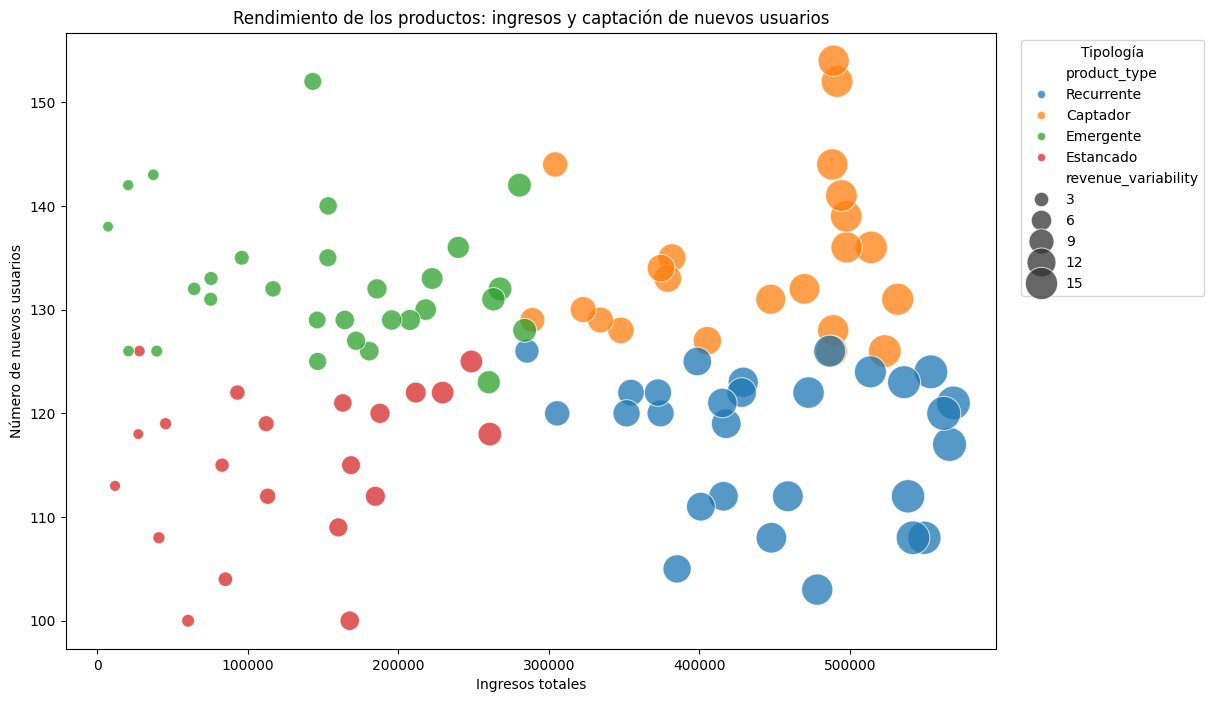

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar datos

products = pd.read_csv("products.csv")

# Convertir price a numérico

products["price"] = (
    products["price"]
    .str.replace("$", "", regex=False)
    .astype(float)
)

# Asegurar que timestamp es datetime

transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"]
)

# 2. Comprobar relación entre amount y precios

# Diccionario producto → precio

product_prices = dict(
    zip(products["id"], products["price"])
)


def calculate_product_price(product_ids):
    ids = str(product_ids).replace(" ", "").split(",")

    total = 0

    for product_id in ids:
        if product_id != "":
            total += product_prices.get(int(product_id), 0)

    return total


transactions["product_price_total"] = (
    transactions["product_ids"]
    .apply(calculate_product_price)
)

# Diferencia entre el importe de la transacción y la suma de precios de catálogo

transactions["price_difference"] = (
    transactions["amount"]
    - transactions["product_price_total"]
)

print("Diferencia entre amount y precio de catálogo:")

display(
    transactions["price_difference"]
    .describe()
    .round(2)
)

# 3. Identificar nuevos usuarios

# Ordenar cronológicamente las transacciones de cada usuario

transactions_product = transactions.sort_values(
    ["user_id", "timestamp", "id"]
).copy()

# La primera transacción de cada usuario es su primera compra

transactions_product["es_nou_usuari"] = (
    ~transactions_product["user_id"].duplicated()
)

# Renombrar el ID de la transacción para evitar conflictos posteriores con products.id

transactions_product = transactions_product.rename(
    columns={"id": "transaction_id"}
)

# 4. Descomponer productos

# Convertir: "20,42,54,46" en: ["20", "42", "54", "46"]

transactions_product["product_ids"] = (
    transactions_product["product_ids"]
    .fillna("")
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.split(",")
)

# Crear una fila por producto

product_transactions = transactions_product.explode(
    "product_ids"
).copy()

# Eliminar filas sin producto

product_transactions = product_transactions[
    product_transactions["product_ids"] != ""
].copy()

# Convertir product_id a entero

product_transactions["product_id"] = (
    product_transactions["product_ids"].astype(int)
)

# 5. Combinar con tabla products

products_aux = products[
    ["id", "product_name", "price"]
].rename(
    columns={"id": "product_id"}
)

product_transactions = product_transactions.merge(
    products_aux,
    on="product_id",
    how="left"
)

# 6. Asignar importe de transacción a cada producto

# Precio total de los productos de cada transacción

product_transactions["transaction_product_total"] = (
    product_transactions
    .groupby("transaction_id")["price"]
    .transform("sum")
)

# Distribuir el importe proporcionalmente al precio de cada producto

product_transactions["product_revenue"] = (
    product_transactions["amount"]
    * product_transactions["price"]
    / product_transactions["transaction_product_total"]
)
# Limitación metodológica

# transactions no proporciona el importe individual de cada producto cuando una
# transacción contiene varios productos. Por ello, distribuimos el amount total
# proporcionalmente según el precio de catálogo de cada producto.
# Esta aproximación evita duplicar los ingresos, pero no permite conocer el
# importe real pagado por cada producto.


# 7. Métricas por producto

product_summary = (
    product_transactions
    .groupby(
        ["product_id", "product_name"]
    )
    .agg(
        total_revenue=("product_revenue", "sum"),

        revenue_variability=(
            "product_revenue",
            lambda x: x.std(ddof=0)
        ),

        buyers=("user_id", "nunique"),

        new_users=("es_nou_usuari", "sum")
    )
    .reset_index().round(2)
)

# 8. Porcentaje de nuevos usuarios

product_summary["new_user_percentage"] = (
    product_summary["new_users"]
    / product_summary["buyers"]
    * 100
).round(2)

# 9. Clasificar productos

# El enunciado no fija umbrales de "alto" y "bajo". Utilizamos la mediana como punto de corte.

revenue_threshold = (
    product_summary["total_revenue"].median()
)

capture_threshold = (
    product_summary["new_user_percentage"].median()
)


def classify_product(row):

    high_revenue = (
        row["total_revenue"] >= revenue_threshold
    )

    high_capture = (
        row["new_user_percentage"] >= capture_threshold
    )

    if high_revenue and high_capture:
        return "Captador"

    elif high_revenue and not high_capture:
        return "Recurrente"

    elif not high_revenue and high_capture:
        return "Emergente"

    else:
        return "Estancado"


product_summary["product_type"] = (
    product_summary.apply(
        classify_product,
        axis=1
    )
)

# Ordenar por ingresos

product_summary = product_summary.sort_values(
    "total_revenue",
    ascending=False
)

# Mostrar el resultado

display(product_summary)

# 10. Visualización

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=product_summary,
    x="total_revenue",
    y="new_users",
    size="revenue_variability",
    hue="product_type",
    sizes=(60, 600),
    alpha=0.75
)

plt.title(
    "Rendimiento de los productos: "
    "ingresos y captación de nuevos usuarios"
)

plt.xlabel("Ingresos totales")
plt.ylabel("Número de nuevos usuarios")

plt.legend(
    title="Tipología",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

print("")
plt.show()

####Interpretación: El análisis muestra cuatro comportamientos diferenciados. Los productos Recurrentes concentran ingresos elevados, pero presentan una menor capacidad de captación de nuevos usuarios, lo que puede generar dependencia de clientes ya existentes. Los Captadores combinan una elevada facturación con una buena capacidad de adquisición y representan los productos más interesantes para el crecimiento. Los Emergentes generan menos ingresos, pero muestran potencial de captación, mientras que los Estancados presentan bajos ingresos y baja captación.

####Riesgo de negocio: Una elevada dependencia de productos Recurrentes puede sostener los ingresos actuales, pero limitar el crecimiento futuro si disminuye la captación de nuevos usuarios. Por ello, es importante equilibrar productos rentables con productos Captadores capaces de ampliar la base de clientes.

####Conclusión: Los productos con mayores ingresos no siempre son los que más nuevos usuarios captan. Los productos Recurrentes aportan una parte importante de los ingresos, pero su baja captación puede generar dependencia de usuarios existentes y limitar el crecimiento futuro. Los productos Captadores son especialmente relevantes porque combinan generación de ingresos y adquisición de nuevos usuarios, mientras que los Emergentes podrían representar oportunidades de crecimiento si consiguen aumentar su volumen de ventas. Los productos Estancados presentan el mayor riesgo al combinar bajos ingresos y baja capacidad de captación. Y no captar nuevos usuarios implica una mayor dependencia de los clientes recurrentes. Aunque los ingresos actuales puedan mantenerse, la base de usuarios deja de crecer y aumenta el riesgo de estancamiento a medio y largo plazo. Además, si algunos usuarios recurrentes dejan de comprar, será más difícil compensar esa pérdida con nuevos clientes.

###Exercici 2: Anàlisi geogràfica company–usuari i oportunitats d'expansió
🎯 Objectiu: Analitzar la relació entre el país de les companyies venedores, el país de residència dels usuaris i el flux de compra entre països.
El negoci està basat en mercats locals (mateix país usuari–companyia) o hi ha una oportunitat real d'expansió internacional obrint més companyies en certs països?

Passos orientatius:

1. Combina les taules necessàries.
2. Crea una variable clau d'anàlisi: compra_local = True/False.
3. Analitza el comportament global:

Percentatge de transaccions locals vs internacionals.
Percentatge de facturació local vs internacional.
4. Anàlisi per país de l'usuari, per cada país d'usuari:

% de compres a companyies del mateix país.
% de compres a companyies estrangeres.
Import total comprat.
5. Anàlisi per país de companyia, per cada país de companyia calcula quina part de la seva facturació ve de:

Usuaris locals.
Usuaris estrangers.
6. Escull una visualització que expliqui clarament el fenomen.
7. Interpretació estratègica:

En quins països valdria la pena obrir més companyies locals?
Hi ha països amb demanda però poca oferta local?
El negoci depèn massa de companyies d'un sol país?
Obrir companyies locals reduiria fricció o milloraria conversió?


Porcentaje de transacciones: 


,proportion
Internacionales,88.14
Locales,11.86




Porcentaje de facturación: 


,amount
Internacionales,88.13
Locales,11.87




Importe total comprado por país:


...

,user_country,international_percentage
10,United States,81.47
9,United Kingdom,82.70
7,Spain,98.26
0,Canada,90.29
4,Netherlands,80.68
6,Portugal,100.00
3,Italy,82.89
2,Germany,83.05
5,Poland,100.00
8,Sweden,78.69




Facturación obtenida de usuarios locales:


compra_local,company_country,local_amount
12,Sweden,528506.31
8,Netherlands,521393.18
13,United Kingdom,491510.15
7,Italy,443472.57
5,Germany,447388.07
4,France,154348.57
14,United States,582931.51
1,Belgium,0.00
10,Norway,0.00
6,Ireland,0.00




Facturación obtenida de usuarios extranjeros:


compra_local,company_country,international_amount
12,Sweden,4398453.06
8,Netherlands,3982226.99
13,United Kingdom,3607005.44
7,Italy,3643876.53
5,Germany,3571679.88
4,France,1261735.69
14,United States,518726.35
1,Belgium,951669.99
10,Norway,809288.82
6,Ireland,714959.02


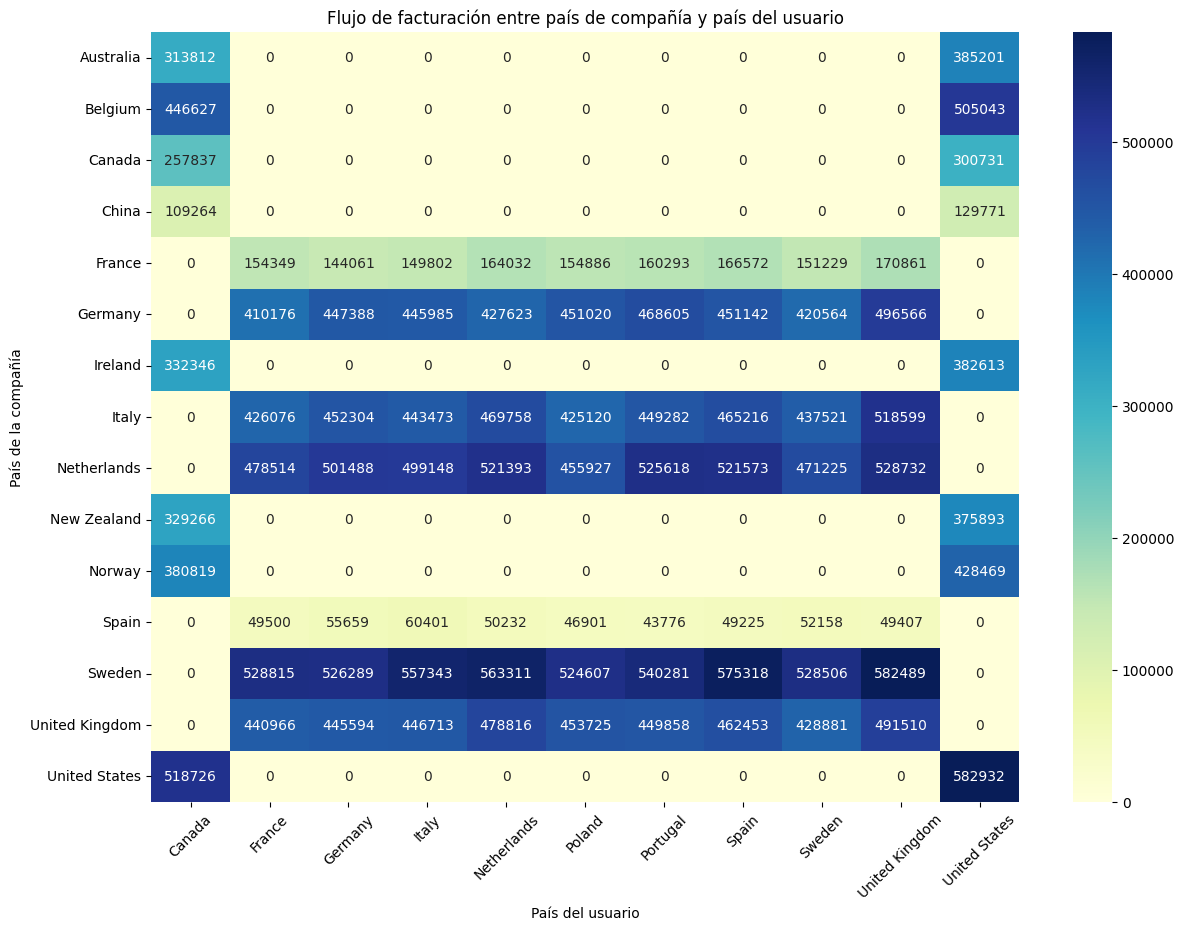

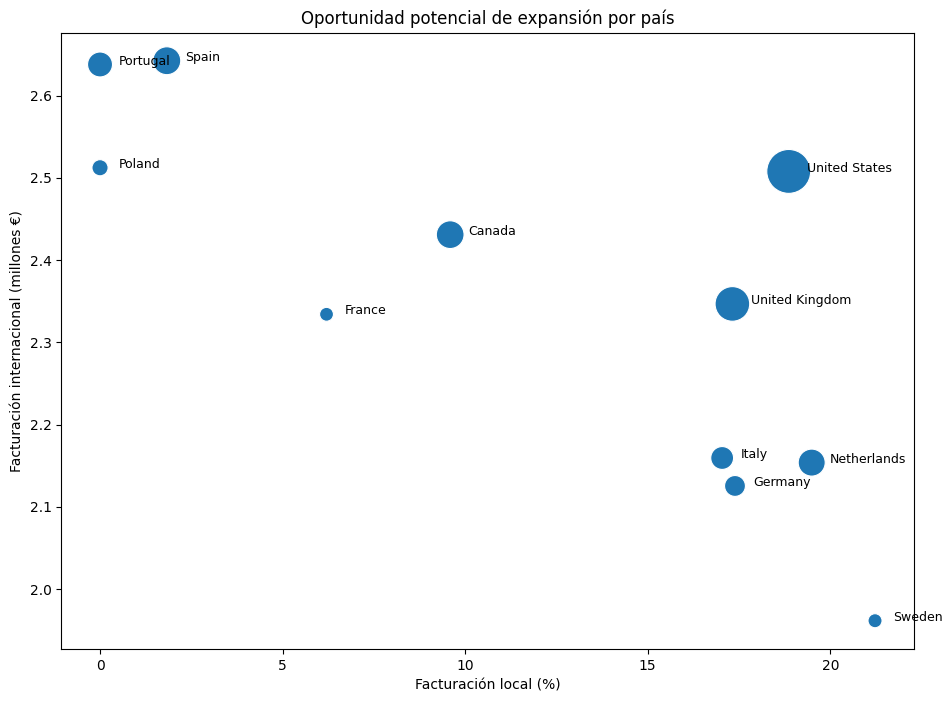

 
El heatmap muestra que existe un flujo significativo de facturación entre distintos países,
por lo que el negocio presenta un marcado componente internacional.

El bubble chart permite identificar mercados con una elevada facturación internacional y una baja
participación de las compras locales, que pueden representar oportunidades potenciales de expansión.
 

Interpretación estratégica:

-¿En qué países valdría la pena abrir más compañías locales?
Portugal, Polonia y España destacan como mercados prioritarios, ya que presentan un volumen relevante
de demanda y una proporción muy elevada de compras a compañías extranjeras.
 
-¿Hay países con demanda pero poca oferta local?
Sí. Portugal y Polonia presentan un 100 % de compras internacionales, mientras que en España las compras locales
representan solo el 1,74 %. Esto indica una posible falta de oferta local.
 
-¿El negocio depende mucho de compañías de un solo país?
No existe una dependencia global de un único país de compañías, ya qu

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los DataFrames

transactions = pd.read_csv("tramnsactions.csv")
companies = pd.read_csv("companies.csv")
users = pd.read_csv("users.csv")

# Convertir tipos de datos

transactions["timestamp"] = pd.to_datetime(
    transactions["timestamp"]
)

# 1. Combinar transactions con companies

analysis = transactions.merge(
    companies[["company_id", "country"]],
    left_on="business_id",
    right_on="company_id",
    how="left"
)

    # Cambiar el nombre del país de la compañía

analysis = analysis.rename(
    columns={"country": "company_country"}
)

  # con users

analysis = analysis.merge(
    users[["id", "country"]],
    left_on="user_id",
    right_on="id",
    how="left"
)

      # Cambiar el nombre del país del usuario

analysis = analysis.rename(
    columns={"country": "user_country"}
)

# 2. Crear compra_local

analysis["compra_local"] = (
    analysis["user_country"]
    == analysis["company_country"]
)

# 3. Análisis global

  #Porcentaje de transacciones locales vs internacionales

transactions_global = (
    analysis["compra_local"]
    .value_counts(normalize=True)
    .mul(100)
)

  # Ponemos más claro

transactions_global.index = [
    "Locales" if value else "Internacionales"
    for value in transactions_global.index
]

print("Porcentaje de transacciones: ",)
display(round(transactions_global,2))

  # Porcentaje de facturación local vs internacional

total_amount_global = (
    analysis.groupby("compra_local")
    ["amount"]
    .sum()
)

total_amount_global = (
    total_amount_global
    / total_amount_global.sum()
    * 100
)

total_amount_global.index = [
    "Locales" if value else "Internacionales"
    for value in total_amount_global.index
]

print("")
print("")
print("Porcentaje de facturación: ",)
display(round(total_amount_global,2))

# 4. Análisis por país de usuario

user_country_summary = (
    analysis.groupby("user_country")
    .agg(
        total_transactions=("amount", "size"),
        total_amount=("amount", "sum"),
        local_transactions=("compra_local", "sum")
    )
    .reset_index()
)

user_country_summary["local_percentage"] = (
    user_country_summary["local_transactions"]
    / user_country_summary["total_transactions"]
    * 100
)

user_country_summary["international_percentage"] = (
    100 - user_country_summary["local_percentage"]
)

user_country_summary = user_country_summary.sort_values(
    "total_amount",
    ascending=False
)

  # Importe total comprado.

print("")
print("")
print("Importe total comprado por país:")
display(user_country_summary[["user_country", "total_amount"]].round(2))

  # % de compras a compañías del mismo país.

print("")
print("")
print("% de compras a compañías del mismo país: ",)
display(user_country_summary[["user_country", "local_percentage"]].round(2))

  # % de compras a compañías extranjeras.

print("")
print("")
print("% de compras a compañías extranjeras: ",)
display(user_country_summary[["user_country", "international_percentage"]].round(2))

# 5. Análisis por país de compañía
company_country_summary = (
    analysis.groupby(["company_country", "compra_local"])["amount"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

company_country_summary = company_country_summary.rename(
    columns={
        True: "local_amount",
        False: "international_amount"
    }
)

company_country_summary["total_amount"] = (
    company_country_summary["local_amount"]
    + company_country_summary["international_amount"]
)

company_country_summary["local_percentage"] = (
    company_country_summary["local_amount"]
    / company_country_summary["total_amount"]
    * 100
)

company_country_summary["international_percentage"] = (
    company_country_summary["international_amount"]
    / company_country_summary["total_amount"]
    * 100
)

company_country_summary = company_country_summary.sort_values(
    "total_amount",
    ascending=False
)

  # facturación obtenida de usuarios locales

print("")
print("")
print("Facturación obtenida de usuarios locales:")
display(company_country_summary[["company_country", "local_amount"]].round(2))

  # facturación obtenida de usuarios extranjeros

print("")
print("")
print("Facturación obtenida de usuarios extranjeros:")
display(company_country_summary[["company_country", "international_amount"]].round(2))

# 6. Escoje una visualización que explique claramente el fenómeno.

country_flow = pd.pivot_table(
    analysis,
    values="amount",
    index="company_country",
    columns="user_country",
    aggfunc="sum",
    fill_value=0
)

# Visualización: Heatmap

plt.figure(figsize=(14, 10))

sns.heatmap(
    country_flow,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title(
    "Flujo de facturación entre país de compañía y país del usuario"
)
plt.xlabel("País del usuario")
plt.ylabel("País de la compañía")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

print("")
print("")
plt.show()


# BUBBLE CHART: Oportunidad potencial de expansión

# Crear resumen por país de usuario

user_country_opportunity = (
    analysis.groupby("user_country")
    .agg(
        total_amount=("amount", "sum"),
        local_amount=(
            "amount",
            lambda x: x[
                analysis.loc[x.index, "compra_local"]
            ].sum()
        )
    )
    .reset_index()
)

# Calcular facturación internacional

user_country_opportunity["international_amount"] = (
    user_country_opportunity["total_amount"]
    - user_country_opportunity["local_amount"]
)

# Calcular porcentaje de facturación local

user_country_opportunity["local_percentage"] = (
    user_country_opportunity["local_amount"]
    / user_country_opportunity["total_amount"]
    * 100
)

# Convertir importes a millones de euros

user_country_opportunity["international_amount_millions"] = (
    user_country_opportunity["international_amount"]
    / 1_000_000
)

user_country_opportunity["total_amount_millions"] = (
    user_country_opportunity["total_amount"]
    / 1_000_000
)

# GRÁFICO

plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=user_country_opportunity,
    x="local_percentage",
    y="international_amount_millions",
    size="total_amount_millions",
    sizes=(100, 1000),
    legend=False
)

# Añadir nombre de cada país

for _, row in user_country_opportunity.iterrows():
    plt.text(
        row["local_percentage"] + 0.5,
        row["international_amount_millions"],
        row["user_country"],
        fontsize=9
    )

plt.title("Oportunidad potencial de expansión por país")
plt.xlabel("Facturación local (%)")
plt.ylabel("Facturación internacional (millones €)")

print("")
print("")
plt.show()

print(" ")
print("El heatmap muestra que existe un flujo significativo de facturación entre distintos países,\npor lo que el negocio presenta un marcado componente internacional.\n\nEl bubble chart permite identificar mercados con una elevada facturación internacional y una baja\nparticipación de las compras locales, que pueden representar oportunidades potenciales de expansión.")

# 7. Interpretación estratégica:

print(" ")
print("")
print("Interpretación estratégica:")
print("")
print("-¿En qué países valdría la pena abrir más compañías locales?")
print("Portugal, Polonia y España destacan como mercados prioritarios, ya que presentan un volumen relevante\nde demanda y una proporción muy elevada de compras a compañías extranjeras.")
print(" ")

print("-¿Hay países con demanda pero poca oferta local?")
print("Sí. Portugal y Polonia presentan un 100 % de compras internacionales, mientras que en España las compras locales\nrepresentan solo el 1,74 %. Esto indica una posible falta de oferta local.")
print(" ")

print("-¿El negocio depende mucho de compañías de un solo país?")
print("No existe una dependencia global de un único país de compañías, ya que la facturación está distribuida entre varias\ngeografías. Sin embargo, algunas geografías presentan una elevada concentración de la demanda en pocos países compradores. \nAustralia, Bélgica, China, Irlanda, Nueva Zelanda y Noruega dependen prácticamente de los mercados de Canadá y Estados \nUnidos, mientras que Estados Unidos y Canadá muestran una fuerte interdependencia entre ambos mercados.")
print(" ")

print("-¿Abrir compañías locales reduciría fricción o mejoraría conversión?")
print("Los datos sugieren que aumentar la oferta local podría reducir la dependencia de compañías extranjeras y\npotencialmente disminuir la fricción de compra. Sin embargo, no podemos demostrar una mejora de la conversión con\nestos datos, por lo que sería necesario contrastarlo con métricas de conversión, costes y comportamiento del cliente.")

##Nivell 3 - Visualització executiva i storytelling

###Exercici 1: Mini-dashboard departamental
🎯 Objectiu: Construeix un mini-dashboard en Python utilitzant Google Colab. Aquest exercici està pensat perquè tot el desenvolupament principal es faci dins del notebook, utilitzant Colab com a eina d'anàlisi i visualització.
L'opció principal i recomanada és la següent.

1. Figura única amb subplots (enfocament analític clàssic)

Construcció d'una única figura amb 4 subplots utilitzant matplotlib i/o seaborn.

Requisits:

1 figura
4 visualitzacions diferents
Si tens temps i vols aprofundir en una solució una mica més complexa, al final es presenten opcions avançades opcionals:

Google Colab està pensat principalment per a treball analític en notebooks. Per aquest motiu, la construcció de dashboards amb Streamlit o Dash no és recomanada dins de Colab, ja que requereix l'execució d'aplicacions web en un entorn local.

Les opcions de dashboard amb Streamlit o Dash es consideren opcions avançades i opcionals, i només s'han de desenvolupar en entorn local de Python.
2. Dashboard interactiu amb Streamlit

Construcció d'una aplicació simple amb Streamlit, orientada a exploració interactiva.

Requisits:

1 pàgina Streamlit
Almenys:
2 filtres
3–4 visualitzacions
Ús de st.sidebar o selectors
3. Dashboard amb Dash

Construcció d'un dashboard web amb Plotly Dash.

Requisits:

Layout amb components.
Callbacks simples.
Almenys 3 visualitzacions connectades.
📌 Condició comuna a TOTES les opcions
Independentment de l'opció triada: el mini-dashboard va orientat a UN dels següents departaments:

» Marketing.
» Vendes / Comercial.
» Producció.
» Sistemes / Ciberseguretat.
Les visualitzacions han de ser:

» Rellevants per al departament escollit.
» Clares i llegibles.
» Coherents entre si.
👉 No es valora la complexitat gràfica, sinó:

» La selecció adequada de mètriques.
» La capacitat de síntesi.
» La coherència del missatge.

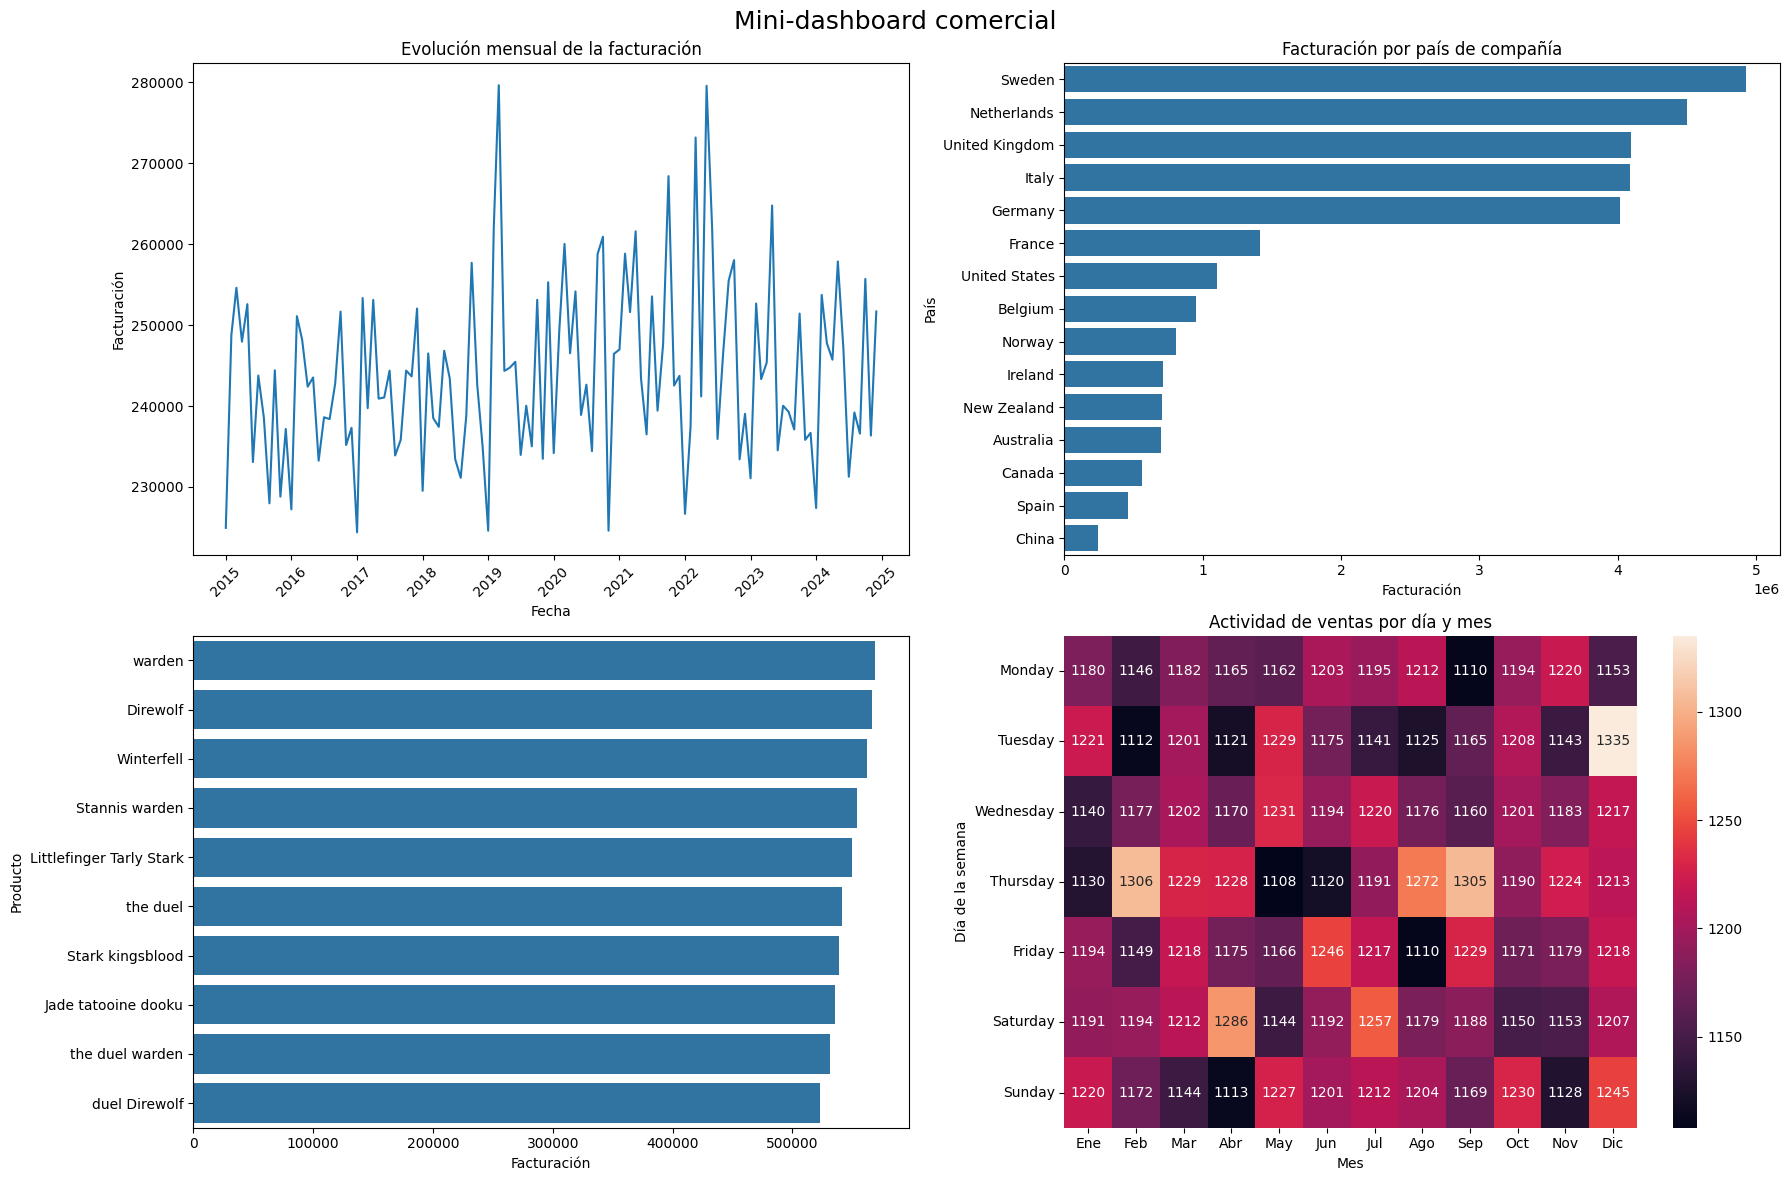

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Preparación de datos

# Copias para evitar modificar los DataFrames originales

tx = transactions.copy()
companies_dashboard = companies.copy()
products_dashboard = products.copy()

# Asegurar tipos

tx["timestamp"] = pd.to_datetime(tx["timestamp"])
tx["amount"] = pd.to_numeric(tx["amount"], errors="coerce")

# Crear variables temporales

tx["year"] = tx["timestamp"].dt.year
tx["month"] = tx["timestamp"].dt.month
tx["month_name"] = tx["timestamp"].dt.strftime("%b")
tx["day_name"] = tx["timestamp"].dt.day_name()


# 2. Facturación mensual

monthly_revenue = (
    tx.groupby(
        ["year", "month"]
    )["amount"]
    .sum()
    .reset_index()
    .sort_values(["year", "month"])
)

# Crear fecha para el eje X

monthly_revenue["date"] = pd.to_datetime(
    monthly_revenue[["year", "month"]]
    .assign(day=1)
)


# 3. Facturación por país de compañía

country_revenue = (
    tx.merge(
        companies_dashboard[["company_id", "country"]],
        left_on="business_id",
        right_on="company_id",
        how="left"
    )
    .groupby("country")["amount"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values("total_revenue", ascending=False)
)

# 4. Preparación de productos

# Convertir precios a numérico

products_dashboard["price"] = (
    products_dashboard["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .astype(float)
)

# Convertir product_ids en listas

tx_products = tx.copy()

tx_products["product_ids"] = (
    tx_products["product_ids"]
    .fillna("")
    .astype(str)
    .str.replace(" ", "", regex=False)
    .str.split(",")
)

# Una fila por producto

product_transactions = (
    tx_products
    .explode("product_ids")
    .copy()
)

# Eliminar vacíos

product_transactions = product_transactions[
    product_transactions["product_ids"] != ""
].copy()

# Convertir a entero

product_transactions["product_id"] = (
    product_transactions["product_ids"]
    .astype(int)
)

# Añadir información del producto

products_aux = (
    products_dashboard[
        ["id", "product_name", "price"]
    ]
    .rename(columns={"id": "product_id"})
)

product_transactions = (
    product_transactions
    .merge(
        products_aux,
        on="product_id",
        how="left"
    )
)

# Calcular valor total de los productos de cada transacción

product_transactions["transaction_product_total"] = (
    product_transactions
    .groupby("id")["price"]
    .transform("sum")
)

# Asignar el importe proporcionalmente

product_transactions["product_revenue"] = (
    product_transactions["amount"]
    * product_transactions["price"]
    / product_transactions["transaction_product_total"]
)

# Ingresos por producto

product_revenue = (
    product_transactions
    .groupby(
        ["product_id", "product_name"]
    )["product_revenue"]
    .sum()
    .reset_index(name="total_revenue")
    .sort_values(
        "total_revenue",
        ascending=False
    )
)

# Top 10 productos
top_products = product_revenue.head(10)

# Top 10 productos

top_products = product_revenue.head(10)

# 5. Actividad por día de semana

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_month_activity = pd.crosstab(
    tx["day_name"],
    tx["month"]
)

day_month_activity = (
    day_month_activity
    .reindex(days_order)
)

day_month_activity.columns = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

# 6. Mini-Dashboard

fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

fig.suptitle(
    "Mini-dashboard comercial",
    fontsize=18
)

# Subplot 1: Evolución de facturación

axes[0, 0].plot(
    monthly_revenue["date"],
    monthly_revenue["amount"]
)

axes[0, 0].set_title(
    "Evolución mensual de la facturación"
)

axes[0, 0].set_xlabel("Fecha")
axes[0, 0].set_ylabel("Facturación")

axes[0, 0].tick_params(
    axis="x",
    rotation=45
)

# Subplot 2: Facturación por país

sns.barplot(
    data=country_revenue,
    x="total_revenue",
    y="country",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Facturación por país de compañía"
)

axes[0, 1].set_xlabel("Facturación")
axes[0, 1].set_ylabel("País")

# Subplot 3: Top 10 productos

sns.barplot(
    data=top_products,
    x="total_revenue",
    y="product_name",
    ax=axes[1, 0]
)

axes[1, 0].set_xlabel("Facturación")
axes[1, 0].set_ylabel("Producto")

# Subplot 4: Actividad semanal

sns.heatmap(
    day_month_activity,
    annot=True,
    fmt=".0f",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Actividad de ventas por día y mes"
)

axes[1, 1].set_xlabel("Mes")
axes[1, 1].set_ylabel("Día de la semana")

# Ajustar espacios

plt.tight_layout()

plt.show()

####Explicación: Primero preparo las fechas y los datos necesarios. Después calculo la facturación mensual, la facturación por país de compañía y los ingresos de los productos. También calculo el número de transacciones por día de la semana y mes. Finalmente, represento las cuatro métricas en una única figura con cuatro subplots para obtener una visión resumida del comportamiento comercial, con la idea de responer a estas preguntas: ¿Cuánto vendemos? → evolución mensual, ¿Dónde vendemos? → países, ¿Qué vendemos? → productos, ¿Cuándo vendemos? → actividad temporal.

#### Interpretación del mini-dashboard

El dashboard ofrece una visión global del rendimiento comercial desde cuatro perspectivas: evolución temporal de la facturación, distribución geográfica, productos con mayor volumen de ventas y comportamiento de la actividad según día y mes.

La mayor parte de la facturación está concentrada en 5 países, mientras que a nivel de productos, son varios los que presentan un volumen de ingresos elevado y similar. La evolución temporal muestra fluctuaciones mensuales, pero sin un crecimiento o descenso sostenido claramente definido. Finalmente, la actividad comercial se mantiene bastante equilibrada entre los diferentes días de la semana, aunque existen algunas diferencias según el mes.

###Exercici 2: Informe executiu
🎯 Objectiu: A partir del dashboard, presenta un informe executiu en dues versions:

Sense IA
Amb suport d'IA
» Sense IA:

Redactada amb les teves pròpies paraules.
» Amb suport d'IA:

Utilitzant eines d'IA per:

Millorar la redacció.
Adaptar el llenguatge al departament escollit.
Incorporar vocabulari tècnic de negoci.
L'informe ha de contenir obligatòriament:

1. Resum general (màx. 5 línies): Què s'ha analitzat i amb quin objectiu.
2. Troballes clau (3-5): Insights sòlids basats en dades reals.
3. Riscos detectats: Per exemple: dependència excessiva de productes o empreses, manca de captació de nous usuaris, franges horàries crítiques, possibles indicis de frau o anomalies...
4. Oportunitats: millores operatives, segments no explotats, productes o franges amb potencial, optimització de recursos...
5. Recomanacions: Accions concretes i no tècniques, orientades a negoci.
📌 Clau del nivell 3

No es tracta de demostrar que saps fer gràfics, sinó de demostrar que entens les dades i saps explicar què s'ha de fer amb elles.

Implementar estratègies comercials orientades a la fidelització i a la previsibilitat del volum de vendes.

##### Sin IA

Informe ejecutivo

1. Resumen general

Se ha analizado el comportamiento de las ventas desde las perspectivas de evolución de la facturación, distribución por país de las compañías, productos con mayores ingresos y actividad según día y mes, con el objetivo de identificar los principales factores que afectan al rendimiento comercial y detectar riesgos y oportunidades para mejorar la estabilidad y el crecimiento de las ventas.

2. Hallazgos clave

- La facturación está repartida entre 15 países, aunque existe una concentración importante: los cinco principales países generan el 73,87 % de la facturación total.
- Suecia es el país de compañías con mayor facturación, con cerca de 5 millones de euros.
- Los productos con mayor facturación presentan valores relativamente próximos, situándose aproximadamente entre 490.000 € y 570.000 €, por lo que no existe una dependencia extrema de un único producto.
- La facturación mensual presenta variaciones, pero no se observa una estacionalidad marcada y constante. Octubre presenta la mayor facturación media y enero la menor.
- La actividad de ventas está bastante equilibrada entre los diferentes días de la semana, sin una concentración extrema en un día concreto.

3. Riesgos detectados

El principal riesgo identificado es la concentración geográfica de la facturación, ya que una parte importante de los ingresos depende de un grupo reducido de países, y practicamente la totalidad se en Europa.

La ausencia de una estacionalidad fuerte es positiva para la estabilidad, pero la concentración geográfica puede hacer que una caída de ventas en alguno de los principales mercados tenga un impacto significativo.

4. Oportunidades

Existe una oportunidad para diversificar la actividad comercial hacia países con menor peso actual y conseguir reducir la dependencia de los principales mercados.

También se puede aprovechar el buen comportamiento de los productos líderes para desarrollar estrategias de fidelización, y utilizar los productos con menor volumen para realizar campañas comerciales que aumenten su participación.

5. Recomendaciones

- Desarrollar programas de fidelización para aumentar la recurrencia de compra.
- Potenciar la venta cruzada y las promociones asociadas a los productos con mayor facturación.
- Diversificar la actividad comercial hacia países con menor peso para reducir la concentración geográfica.
- Utilizar los patrones mensuales de ventas para planificar campañas.
- Realizar un seguimiento periódico de la facturación por país y producto para detectar cambios lo más rápidamente posible y evitar una grave afectación al negocio.

##### Con IA

Informe ejecutivo — Departamento Comercial

1. Resumen general

El análisis evalúa el rendimiento comercial desde cuatro dimensiones: evolución temporal de la facturación, concentración geográfica, contribución de los principales productos y patrones de actividad. El objetivo es identificar los principales riesgos de concentración y detectar oportunidades para mejorar la estabilidad, la fidelización y la previsibilidad de los ingresos.

2. Hallazgos clave

- La facturación presenta una concentración geográfica relevante: los cinco principales países de compañías concentran el 73,87 % del volumen total, aunque ningún país individual supera el 17 %.
- Suecia lidera la facturación por país de compañía con aproximadamente 4,93 M€, seguida de Países Bajos, Reino Unido, Italia y Alemania.
- Los principales productos presentan niveles de facturación relativamente homogéneos, aproximadamente entre 494.000 € y 569.000 €, reduciendo el riesgo de dependencia exclusiva de un único producto.
- El comportamiento temporal presenta fluctuaciones mensuales, pero no muestra una estacionalidad fuerte y sistemática. La facturación media alcanza su máximo en octubre (254.586 €) y su mínimo en enero (229.703 €).
- La actividad comercial está distribuida de forma bastante equilibrada entre los días de la semana, sin una concentración estructural en una única jornada.

3. Riesgos detectados

El principal riesgo es la concentración de ingresos en un número reducido de mercados geográficos. Aunque no existe dependencia de un único país, el peso conjunto de los cinco principales mercados hace que cambios regulatorios, económicos o comerciales en estas geografías puedan tener un impacto significativo sobre el negocio.

La concentración en los productos de mayor facturación constituye un segundo riesgo, aunque actualmente está mitigado por la existencia de varios productos con contribuciones similares.

4. Oportunidades

La relativa estabilidad del volumen de ventas a lo largo de la semana y la ausencia de una estacionalidad extrema favorecen una mayor previsibilidad operativa.

La principal oportunidad comercial consiste en reforzar la fidelización de los clientes y aumentar la recurrencia de compra sobre los productos de mayor rendimiento. Paralelamente, la diversificación hacia mercados actualmente menos relevantes permitiría reducir el riesgo de concentración geográfica.

Los patrones mensuales también pueden utilizarse para anticipar periodos de mayor o menor demanda y ajustar campañas comerciales, objetivos y recursos.

5. Recomendaciones

- Implantar una estrategia de fidelización orientada a incrementar la frecuencia de compra y el valor recurrente del cliente.
- Potenciar acciones de venta cruzada y recomendaciones alrededor de los productos con mayor rendimiento.
- Establecer objetivos de diversificación geográfica para reducir progresivamente la dependencia de los cinco principales mercados.
- Planificar campañas comerciales y recursos con mayor intensidad en los periodos históricamente más favorables, utilizando el comportamiento mensual como referencia.
- Definir un seguimiento periódico de indicadores de concentración por país y producto para anticipar riesgos y mejorar la previsibilidad del volumen de ventas.